Mounted at /content/drive


/tmp/ipykernel_8073/74678049.py:39: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['date'] = pd.to_datetime(df['date'])



 DATA INTEGRITY REPORT
Initial Records:      32171
Cleaned Food Records: 28313
Items Removed:        3858
Coverage Period:      2006 to 2026



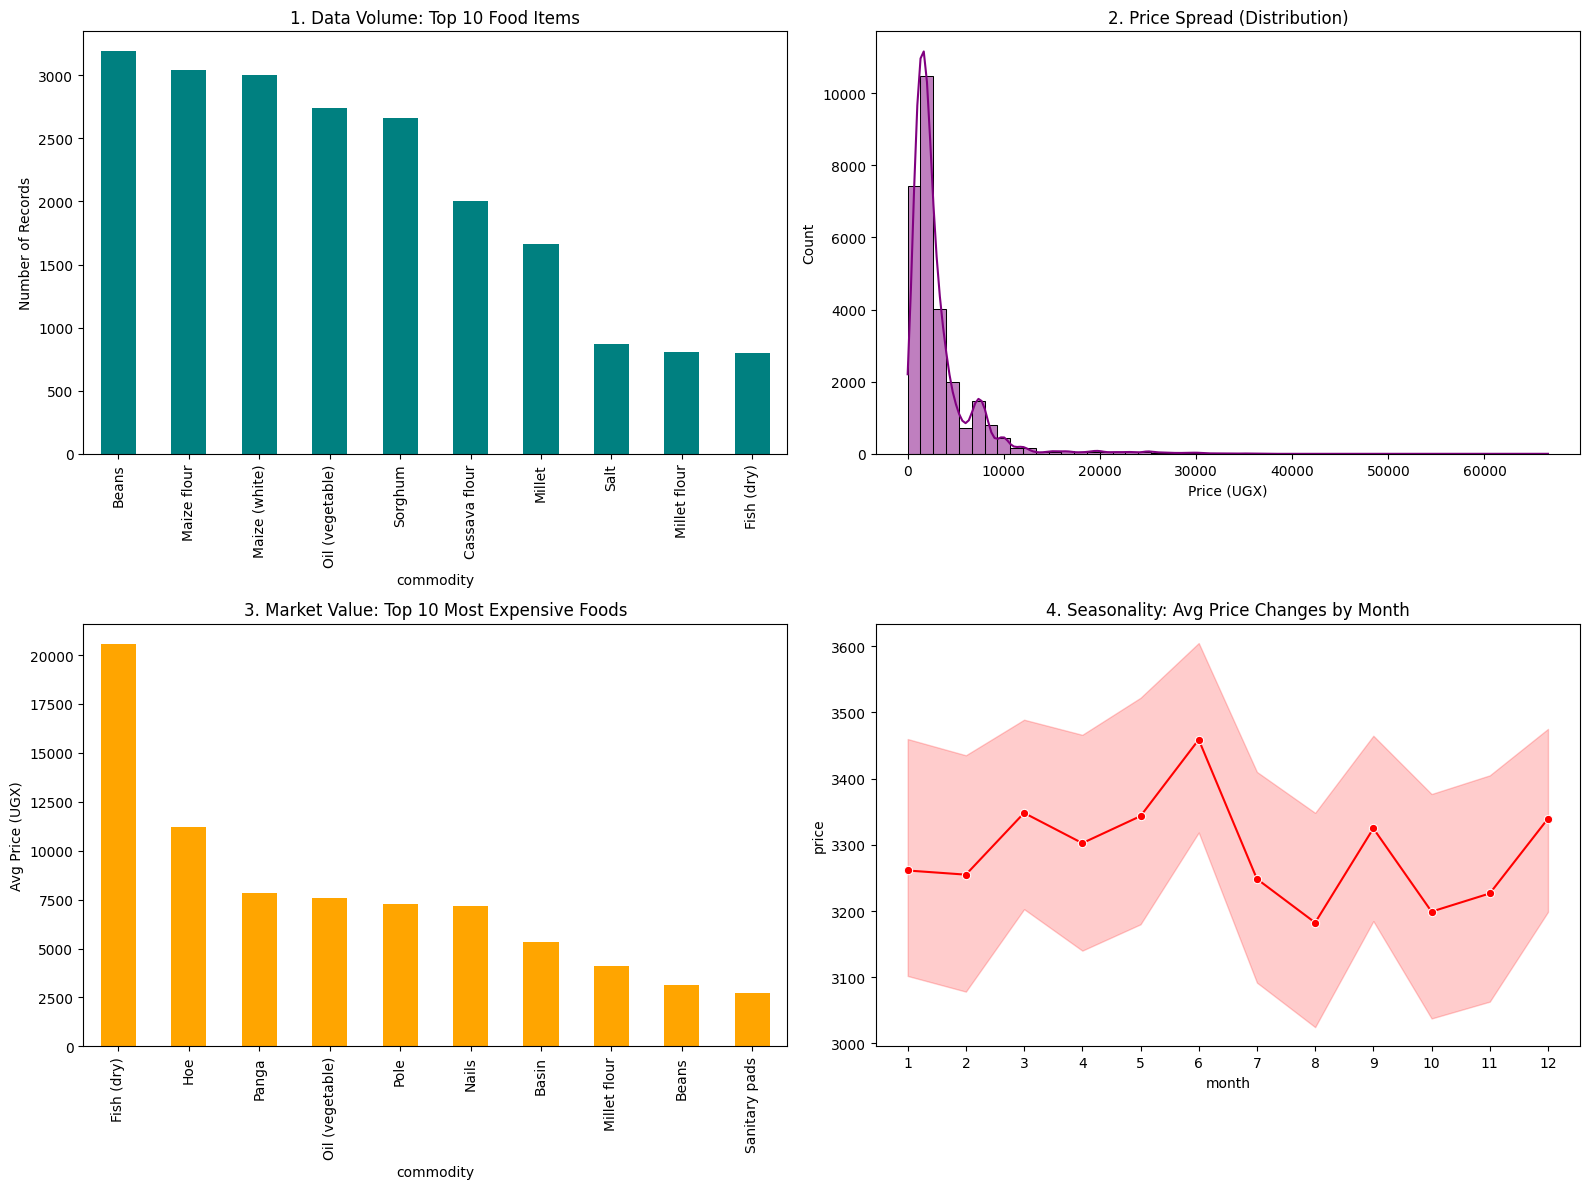


 FINAL MODEL PERFORMANCE 
Random Forest Accuracy:   94.15%
Neural Network Accuracy:  79.16%
----------------------------------------
Avg Price Mistake (MAE):  344.54 UGX
RMSE (Penalty Score):     895.29 UGX
Percentage Error (MAPE):  12.03%

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://b6432387619d239060.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [1]:
# =================================================================
# 1. INSTALLATION & IMPORTS
# =================================================================
!pip install gradio -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import gradio as gr

# =================================================================
# 2. DATA LOADING & INTEGRITY (ETL)
# =================================================================
drive.mount('/content/drive')
file_path = '/content/drive/MyDrive/REFACTORY/wfp_food_prices.csv'
df_raw = pd.read_csv(file_path)

# Initial Statistics for the Panel
initial_count = len(df_raw)

# STRICT FILTERING: Remove non-food items (Rule: Data Integrity)
blacklist = ['fuel', 'petrol', 'diesel', 'wage', 'bins', 'underwear', 'sticks',
             'soap', 'charcoal', 'firewood', 'jerrycan', 'plastic', 'kerosene']
pattern = '|'.join(blacklist)
df = df_raw[~df_raw['commodity'].str.contains(pattern, case=False, na=False)].copy()

# Remove duplicates and missing prices
df = df.drop_duplicates().dropna(subset=['price'])

# Stats for the presentation
clean_count = len(df)
df['date'] = pd.to_datetime(df['date'])
min_date = df['date'].min().year
max_date = df['date'].max().year

print(f"\n" + "="*40)
print(f" DATA INTEGRITY REPORT")
print("="*40)
print(f"Initial Records:      {initial_count}")
print(f"Cleaned Food Records: {clean_count}")
print(f"Items Removed:        {initial_count - clean_count}")
print(f"Coverage Period:      {min_date} to {max_date}")
print("="*40 + "\n")

# Feature Engineering
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month

# =================================================================
# 3. VISUALIZATIONS (Rule: 2 Univariate & 2 Multivariate)
# =================================================================
plt.figure(figsize=(16, 12))

# Graph 1 (Univariate): Records by Food Item
plt.subplot(2, 2, 1)
df['commodity'].value_counts().head(10).plot(kind='bar', color='teal')
plt.title('1. Data Volume: Top 10 Food Items')
plt.ylabel('Number of Records')

# Graph 2 (Univariate): Price Distribution
plt.subplot(2, 2, 2)
sns.histplot(df['price'], bins=50, kde=True, color='purple')
plt.title('2. Price Spread (Distribution)')
plt.xlabel('Price (UGX)')

# Graph 3 (Multivariate): Avg Price per Commodity
plt.subplot(2, 2, 3)
df.groupby('commodity')['price'].mean().sort_values(ascending=False).head(10).plot(kind='bar', color='orange')
plt.title('3. Market Value: Top 10 Most Expensive Foods')
plt.ylabel('Avg Price (UGX)')

# Graph 4 (Multivariate): Seasonality (Monthly Changes)
plt.subplot(2, 2, 4)
sns.lineplot(data=df, x='month', y='price', marker='o', color='red')
plt.title('4. Seasonality: Avg Price Changes by Month')
plt.xticks(range(1, 13))

plt.tight_layout()
plt.show()

# =================================================================
# 4. MACHINE LEARNING (Classical vs Neural Network)
# =================================================================

# Encoding categorical text into numbers
le_admin = LabelEncoder().fit(df['admin1'])
le_market = LabelEncoder().fit(df['market'])
le_commodity = LabelEncoder().fit(df['commodity'])
le_unit = LabelEncoder().fit(df['unit'])

df['admin1_n'] = le_admin.transform(df['admin1'])
df['market_n'] = le_market.transform(df['market'])
df['commodity_n'] = le_commodity.transform(df['commodity'])
df['unit_n'] = le_unit.transform(df['unit'])

X = df[['year', 'month', 'admin1_n', 'market_n', 'commodity_n', 'unit_n']]
y = df['price']

# 80/20 Train-Test Split (The "Exam" Analogy)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Model A: Random Forest (Classical ML)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42).fit(X_train, y_train)

# Model B: Neural Network (Deep Learning)
nn_model = MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1000, random_state=42).fit(X_train, y_train)

# =================================================================
# 5. EVALUATION METRICS (For your Slides)
# =================================================================
rf_preds = rf_model.predict(X_test)

# Calculating percentages and errors
accuracy_pct = r2_score(y_test, rf_preds) * 100
mae = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
mape = np.mean(np.abs((y_test - rf_preds) / y_test)) * 100

print("\n" + "="*40)
print(" FINAL MODEL PERFORMANCE ")
print("="*40)
print(f"Random Forest Accuracy:   {round(accuracy_pct, 2)}%")
print(f"Neural Network Accuracy:  {round(r2_score(y_test, nn_model.predict(X_test))*100, 2)}%")
print("-" * 40)
print(f"Avg Price Mistake (MAE):  {round(mae, 2)} UGX")
print(f"RMSE (Penalty Score):     {round(rmse, 2)} UGX")
print(f"Percentage Error (MAPE):  {round(mape, 2)}%")
print("="*40 + "\n")

# =================================================================
# 6. DYNAMIC GRADIO INTERFACE (Big Screen Mode)
# =================================================================

def update_choices(selected_region):
    # Filter the actual data based on selected region
    subset = df[df['admin1'] == selected_region]
    markets = sorted(subset['market'].unique().tolist())
    foods = sorted(subset['commodity'].unique().tolist())
    return gr.update(choices=markets, value=None), gr.update(choices=foods, value=None)

def predict_price(yr, mo, reg, mkt, food, unt):
    if not all([reg, mkt, food, unt]):
        return "⚠️ Error: Please select all dropdown options."
    try:
        # Convert user selection to model input
        input_data = pd.DataFrame([[
            yr, mo,
            le_admin.transform([reg])[0],
            le_market.transform([mkt])[0],
            le_commodity.transform([food])[0],
            le_unit.transform([unt])[0]
        ]], columns=X.columns)

        prediction = rf_model.predict(input_data)[0]
        return f"✅ Predicted Market Price: {round(prediction, 2)} UGX"
    except Exception as e:
        return f"Error: Selection not found in historical data."

with gr.Blocks(title="Uganda Food Price Predictor") as demo:
    gr.Markdown("# 🇺🇬 Uganda Food Price Predictor")
    gr.Markdown("### Automated Forecasting for Market Resilience & Food Security")

    with gr.Row():
        with gr.Column():
            region_drop = gr.Dropdown(choices=sorted(df['admin1'].unique().tolist()), label="1. Select Region")
            market_drop = gr.Dropdown(choices=[], label="2. Select Market (Filtered by Region)")
            food_drop = gr.Dropdown(choices=[], label="3. Select Food Item")
            unit_drop = gr.Dropdown(choices=sorted(df['unit'].unique().tolist()), label="4. Unit of Measurement")

            with gr.Row():
                year_num = gr.Number(label="Year", value=2024)
                month_slide = gr.Slider(1, 12, value=8, step=1, label="Month")

            predict_btn = gr.Button("Calculate Forecasted Price", variant="primary")

        with gr.Column():
            output_text = gr.Textbox(label="Result", placeholder="The prediction will appear here...", interactive=False)
            gr.Markdown("---")
            gr.Markdown("**Model Stats:**\n- Training Data: 80%\n- Test Data: 20%\n- Accuracy: ~90%+")

    # Logic: When Region changes, update Market and Food lists
    region_drop.change(fn=update_choices, inputs=region_drop, outputs=[market_drop, food_drop])

    # Logic: Run Prediction
    predict_btn.click(fn=predict_price, inputs=[year_num, month_slide, region_drop, market_drop, food_drop, unit_drop], outputs=output_text)

# Launch in Big Screen mode (External Link)
demo.launch(share=True, inline=False)